# Symmetry Detection

In [1]:
import sys
import time
from pathlib import Path
import open3d as o3d
import trimesh
import numpy as np
sys.path.insert(0, '../')
import drm
from drm.detect import detect_symmetry_o3d, symmetry_geometries, reflect_pointcloud

%load_ext autoreload
%autoreload 2

path = "/home/jvermandere/datasets/V-Scan/data/Office_1_Leica-P30_1775812376935/Chair Guest Green(Clone)1775812376937_points.txt"

# Works directly with your txt_pcd_to_open3d() output
pcd, matrix = drm.txt_pcd_to_open3d(path)
drm.visualise_open3d(pcd).show()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded 12232 points from /home/jvermandere/datasets/V-Scan/data/Office_1_Leica-P30_1775812376935/Chair Guest Green(Clone)1775812376937_points.txt


In [ ]:

result = detect_symmetry_o3d(pcd, threshold=0.02, n_random_candidates=600)
print(result)
# → plane_normal, plane_point, score, threshold


In [ ]:

# Get Open3D geometries for your visualiser
geoms = symmetry_geometries(result, pcd)          # axis + plane + reflected cloud
scene = drm.visualise_open3d([pcd] + geoms)       # your existing helper
scene.show()


In [ ]:
# Or get the mirrored cloud as a proper o3d PointCloud (colors + normals preserved)
pcd_reflected = reflect_pointcloud(pcd, result)
drm.visualise_open3d(pcd_reflected).show()

## Shapenet experiments

In [44]:
import os
import glob
import time
import warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple
 
import numpy as np
import open3d as o3d
import sys
sys.path.insert(0, '../')
import drm
from drm.detect import (
    detect_multi_symmetry_o3d,
    MultiSymmetryResult,
    SymmetryResult,
    _plane_normal_angle_deg,
)
 
 
# ── Known ShapeNet synset → human-readable name ────────────────────────────────
SHAPENET_SYNSETS: Dict[str, str] = {
    "02691156": "airplane",
    "02828884": "bench",
    "02933112": "cabinet",
    "02958343": "car",
    "03001627": "chair",
    "03211117": "display",
    "03636649": "lamp",
    "03691459": "loudspeaker",
    "03790512": "motorbike",
    "03948459": "pistol",
    "04090263": "rifle",
    "04256520": "sofa",
    "04379243": "table",
    "04401088": "telephone",
    "04530566": "watercraft",
}
 
 
# ═══════════════════════════════════════════════════════════════════════════════
#  Result dataclasses
# ═══════════════════════════════════════════════════════════════════════════════
 
@dataclass
class AxisMatchResult:
    """
    One partial-cloud axis matched against its nearest full-cloud axis.
 
    The partial axis is the detected one; the full axis is the reference it
    was matched to (lowest angular distance among all full-cloud axes).
    Both axes are ranked by detection score within their own cloud.
    """
    partial_rank:   int          # 0 = best partial axis, 1 = second best, …
    partial_normal: np.ndarray   # (3,) unit normal from partial cloud
    partial_score:  float        # symmetry score on partial cloud
 
    full_rank:      int          # which full-cloud axis this matched (0 = best)
    full_normal:    np.ndarray   # (3,) unit normal from full cloud (closest match)
    full_score:     float        # symmetry score on full cloud
 
    angular_error_deg: float     # angle between partial and matched full normal [0–90°]
    found:          bool         # True if angular_error_deg < max_match_deg
 
 
@dataclass
class ShapeSymmetryResult:
    """Symmetry comparison result for a single shape (multi-axis, NN matching)."""
    obj_path:           str
 
    multi_full:         MultiSymmetryResult   # axes on full cloud (reference)
    n_points_full:      int
 
    multi_partial:      MultiSymmetryResult   # axes on partial cloud
    n_points_partial:   int
    camera_pos:         np.ndarray
 
    # One entry per partial axis (len = multi_partial.k), ordered by partial score
    axis_matches:       List[AxisMatchResult]
 
    # Convenience aggregates over found matches only
    errors_deg:         List[float]   # angular_error_deg for each partial axis (found or 90°)
    found_fraction:     float         # fraction of partial axes within max_match_deg
    mean_score_full:    float
    mean_score_partial: float
 
    elapsed_full_s:     float
    elapsed_partial_s:  float
 
    def __str__(self) -> str:
        name = Path(self.obj_path).parents[1].name
        lines = [
            f"ShapeSymmetryResult [{name}]",
            f"  pts full/partial    : {self.n_points_full} / {self.n_points_partial}  "
            f"({self.n_points_partial/self.n_points_full*100:.0f}% visible)",
            f"  axes full / partial : {self.multi_full.k} / {self.multi_partial.k}",
            f"  {'#':>2}  {'partial normal':>22}  sc_p  →  {'full normal':>22}  sc_f  err°  ok",
        ]
        for m in self.axis_matches:
            tag = "✓" if m.found else "✗"
            pn  = f"[{m.partial_normal[0]:+.2f},{m.partial_normal[1]:+.2f},{m.partial_normal[2]:+.2f}]"
            fn  = f"[{m.full_normal[0]:+.2f},{m.full_normal[1]:+.2f},{m.full_normal[2]:+.2f}]"
            lines.append(
                f"  {m.partial_rank:>2}  {pn:>22}  {m.partial_score:.2f}  →  "
                f"{fn:>22}  {m.full_score:.2f}  {m.angular_error_deg:5.1f}°  {tag}"
            )
        lines.append(
            f"  found {self.found_fraction*100:.0f}% of partial axes  |  "
            f"errors: {[f'{e:.1f}°' for e in self.errors_deg]}"
        )
        return "\n".join(lines)
 
 
@dataclass
class ClassBenchmarkResult:
    """Aggregated symmetry benchmark for one ShapeNet class."""
    synset_id:      str
    class_name:     str
    n_shapes:       int
    k:              int            # max partial axes compared per shape
 
    # Per partial-axis-rank errors (index 0 = primary axis, 1 = secondary, …)
    # Each list has length = number of shapes that had that axis
    errors_by_rank: List[List[float]]   # errors_by_rank[rank][shape_idx]
 
    # Aggregate over all partial axes across all shapes
    mean_angular_error_deg:  float
    std_angular_error_deg:   float
 
    # Per-rank summaries
    mean_error_by_rank:  List[float]   # mean error for rank-0, rank-1, …
    found_rate_by_rank:  List[float]   # fraction found (< max_match_deg) per rank
 
    mean_fraction_visible:   float
    mean_score_full:         float
    mean_score_partial:      float
 
    per_shape: List[ShapeSymmetryResult] = field(default_factory=list, repr=False)
    found_by_rank: List[List[bool]] = field(default_factory=list)
 
    def __str__(self) -> str:
        lines = [f"═══ {self.class_name} ({self.synset_id}) | n={self.n_shapes} | k={self.k} ═══"]
        lines.append(f"  Overall mean error : {self.mean_angular_error_deg:.2f}° ± {self.std_angular_error_deg:.2f}°")
        for rank, (mean_e, found_r) in enumerate(zip(self.mean_error_by_rank, self.found_rate_by_rank)):
            label = {0: "primary", 1: "secondary", 2: "tertiary"}.get(rank, f"rank-{rank}")
            n = len(self.errors_by_rank[rank])
            lines.append(
                f"  {label:>10} axis : mean={mean_e:5.2f}°  found={found_r*100:4.1f}%  (n={n})"
            )
        lines.append(f"  Visible frac       : {self.mean_fraction_visible*100:.1f}%")
        lines.append(f"  Score full/partial : {self.mean_score_full:.3f} / {self.mean_score_partial:.3f}")
        return "\n".join(lines)
 
 
# ═══════════════════════════════════════════════════════════════════════════════
#  1. Load ShapeNet mesh as point cloud
# ═══════════════════════════════════════════════════════════════════════════════
 
def load_shapenet_pcd(
    obj_path:  str,
    n_points:  int  = 4096,
    method:    str  = "poisson",   # "poisson" | "uniform"
    normalize: bool = True,
) -> o3d.geometry.PointCloud:
    """
    Load a ShapeNet model_normalized.obj and sample it into a point cloud.
 
    Parameters
    ----------
    obj_path  : path to model_normalized.obj
    n_points  : number of points to sample
    method    : "poisson" for Poisson-disk (more uniform) or "uniform" for random
    normalize : centre and scale to fit inside a unit sphere
 
    Returns
    -------
    o3d.geometry.PointCloud with normals
    """
    mesh = o3d.io.read_triangle_mesh(str(obj_path))
 
    if not mesh.has_vertices():
        raise ValueError(f"Could not load mesh or mesh is empty: {obj_path}")
 
    mesh.compute_vertex_normals()
 
    if method == "poisson":
        # init_factor controls the oversampling before thinning; 5 is a safe default
        pcd = mesh.sample_points_poisson_disk(
            number_of_points=n_points,
            init_factor=5,
        )
    else:
        pcd = mesh.sample_points_uniformly(number_of_points=n_points)
 
    if normalize:
        pts     = np.asarray(pcd.points)
        centroid = pts.mean(axis=0)
        scale    = np.linalg.norm(pts - centroid, axis=1).max()
        if scale > 1e-8:
            pcd.points = o3d.utility.Vector3dVector((pts - centroid) / scale)
 
    return pcd
 
 
# ═══════════════════════════════════════════════════════════════════════════════
#  2. Simulate partial view via hidden-point removal
# ═══════════════════════════════════════════════════════════════════════════════
 
def simulate_partial_view(
    pcd:            o3d.geometry.PointCloud,
    distance:       float = 2.5,
    radius_factor:  float = 100.0,
    seed:           Optional[int] = None,
) -> Tuple[o3d.geometry.PointCloud, np.ndarray]:
    """
    Pick a random viewpoint on a sphere of radius *distance* and remove all
    points not visible from that viewpoint using Open3D's hidden_point_removal.
 
    Parameters
    ----------
    pcd           : input point cloud (should be normalised to unit sphere)
    distance      : camera distance from origin (set > max cloud extent)
    radius_factor : HPR radius = distance * radius_factor; larger = more inclusive
    seed          : RNG seed for the random viewpoint
 
    Returns
    -------
    pcd_partial : visible-only point cloud
    camera_pos  : (3,) camera position used
    """
    rng   = np.random.default_rng(seed)
    # Uniform sphere sampling (Marsaglia / equal-area method)
    theta = rng.uniform(0.0, 2.0 * np.pi)
    phi   = np.arccos(rng.uniform(-1.0, 1.0))
    camera_pos = distance * np.array([
        np.sin(phi) * np.cos(theta),
        np.sin(phi) * np.sin(theta),
        np.cos(phi),
    ])
 
    hpr_radius = distance * radius_factor
    _, pt_map  = pcd.hidden_point_removal(camera_pos, hpr_radius)
 
    pcd_partial = pcd.select_by_index(pt_map)
    return pcd_partial, camera_pos
 
 
# ═══════════════════════════════════════════════════════════════════════════════
#  3. Compare multi-axis symmetry: each partial axis → nearest full axis
# ═══════════════════════════════════════════════════════════════════════════════
 
def match_symmetry_axes(
    multi_full:    MultiSymmetryResult,
    multi_partial: MultiSymmetryResult,
    max_match_deg: float = 45.0,
) -> List[AxisMatchResult]:
    """
    For each partial-cloud axis (ordered by score, best first), find the
    nearest full-cloud axis by angular distance.
 
    Multiple partial axes can match the same full axis — this is intentional.
    For example, if a chair has one strong symmetry plane and the partial view
    detects it twice (with slight noise), both should report a small error
    against the same full-cloud reference, not be penalised.
 
    Parameters
    ----------
    multi_full    : axes detected on full cloud (reference set)
    multi_partial : axes detected on partial cloud
    max_match_deg : error threshold; above this, found=False [degrees]
 
    Returns
    -------
    List[AxisMatchResult], one per partial axis, ordered by partial score rank
    """
    normals_f = multi_full.normals    # (K_f, 3)
    normals_p = multi_partial.normals # (K_p, 3)
    K_f = len(normals_f)
 
    matches: List[AxisMatchResult] = []
 
    for p_rank, (pn, p_ax) in enumerate(zip(normals_p, multi_partial.axes)):
        if K_f == 0:
            matches.append(AxisMatchResult(
                partial_rank=p_rank, partial_normal=pn, partial_score=p_ax.score,
                full_rank=0, full_normal=np.zeros(3), full_score=0.0,
                angular_error_deg=90.0, found=False,
            ))
            continue
 
        # Compute angle from this partial axis to every full axis
        angles = np.array([_plane_normal_angle_deg(pn, fn) for fn in normals_f])
        best_f = int(np.argmin(angles))
        err    = float(angles[best_f])
 
        matches.append(AxisMatchResult(
            partial_rank  = p_rank,
            partial_normal= pn,
            partial_score = p_ax.score,
            full_rank     = best_f,
            full_normal   = normals_f[best_f],
            full_score    = multi_full.axes[best_f].score,
            angular_error_deg = err,
            found         = err < max_match_deg,
        ))
 
    return matches
 
 
def compare_symmetry(
    pcd_full:      o3d.geometry.PointCloud,
    pcd_partial:   o3d.geometry.PointCloud,
    camera_pos:    np.ndarray,
    obj_path:      str   = "",
    k:             int   = 3,
    sym_kwargs:    Optional[dict] = None,
    max_match_deg: float = 45.0,
) -> ShapeSymmetryResult:
    """
    Detect K symmetry axes on both clouds, then match each partial axis to
    its nearest full-cloud axis.
 
    Parameters
    ----------
    pcd_full      : full point cloud (reference)
    pcd_partial   : partial (visible-only) point cloud
    camera_pos    : camera used for HPR (stored for reference)
    obj_path      : source path label
    k             : number of axes to detect per cloud
    sym_kwargs    : extra kwargs for detect_multi_symmetry_o3d()
    max_match_deg : angle above which a partial axis is considered not found
 
    Returns
    -------
    ShapeSymmetryResult
    """
    kw = dict(k=k, verbose=False)
    if sym_kwargs:
        kw.update(sym_kwargs)
 
    t0           = time.perf_counter()
    multi_full   = detect_multi_symmetry_o3d(pcd_full, **kw)
    elapsed_full = time.perf_counter() - t0
 
    t1              = time.perf_counter()
    multi_partial   = detect_multi_symmetry_o3d(pcd_partial, **kw)
    elapsed_partial = time.perf_counter() - t1
 
    matches = match_symmetry_axes(multi_full, multi_partial, max_match_deg=max_match_deg)
 
    errors        = [m.angular_error_deg for m in matches]
    found_frac    = float(np.mean([m.found for m in matches])) if matches else 0.0
 
    return ShapeSymmetryResult(
        obj_path          = obj_path,
        multi_full        = multi_full,
        n_points_full     = len(pcd_full.points),
        multi_partial     = multi_partial,
        n_points_partial  = len(pcd_partial.points),
        camera_pos        = camera_pos,
        axis_matches      = matches,
        errors_deg        = errors,
        found_fraction    = found_frac,
        mean_score_full   = float(np.mean(multi_full.scores))   if multi_full.k   else 0.0,
        mean_score_partial= float(np.mean(multi_partial.scores)) if multi_partial.k else 0.0,
        elapsed_full_s    = elapsed_full,
        elapsed_partial_s = elapsed_partial,
    )
 
 
# ═══════════════════════════════════════════════════════════════════════════════
#  4. Benchmark a single class folder
# ═══════════════════════════════════════════════════════════════════════════════
 
def benchmark_class(
    class_dir:      str,
    n_shapes:       Optional[int] = None,
    n_points:       int   = 4096,
    sample_method:  str   = "poisson",
    distance:       float = 2.5,
    radius_factor:  float = 100.0,
    k:              int   = 3,
    sym_kwargs:     Optional[dict] = None,
    max_match_deg:  float = 45.0,
    seed:           int   = 42,
    verbose:        bool  = True,
) -> ClassBenchmarkResult:
    """
    Run the full→partial multi-axis symmetry benchmark for one ShapeNet class folder.
 
    Parameters
    ----------
    class_dir     : path to the synset folder, e.g. '.../ShapeNet/03001627'
    n_shapes      : how many shapes to evaluate (None = all)
    n_points      : points to sample per mesh
    sample_method : "poisson" or "uniform"
    distance      : HPR camera distance
    radius_factor : HPR radius = distance * radius_factor
    k             : number of symmetry axes to detect per cloud
    sym_kwargs    : extra kwargs for detect_multi_symmetry_o3d()
    max_match_deg : angle threshold for declaring an axis pair matched
    seed          : base RNG seed
    verbose       : print per-shape progress
 
    Returns
    -------
    ClassBenchmarkResult
    """
    class_dir  = Path(class_dir)
    synset_id  = class_dir.name
    class_name = SHAPENET_SYNSETS.get(synset_id, synset_id)
 
    obj_files = sorted(glob.glob(
        str(class_dir / "**" / "models" / "model_normalized.obj"),
        recursive=True,
    ))
 
    if not obj_files:
        raise FileNotFoundError(
            f"No model_normalized.obj files found under {class_dir}\n"
            f"Expected: {class_dir}/<shape_id>/models/model_normalized.obj"
        )
 
    if n_shapes is not None:
        rng_sel   = np.random.default_rng(seed)
        obj_files = list(rng_sel.choice(obj_files, size=min(n_shapes, len(obj_files)), replace=False))
 
    if verbose:
        print(f"\n[benchmark] {class_name} ({synset_id}) | {len(obj_files)} shapes | k={k}")
 
    per_shape: List[ShapeSymmetryResult] = []
 
    for i, obj_path in enumerate(obj_files):
        shape_seed = seed + i
        try:
            pcd_full             = load_shapenet_pcd(obj_path, n_points=n_points, method=sample_method)
            pcd_partial, cam     = simulate_partial_view(pcd_full, distance=distance,
                                                         radius_factor=radius_factor, seed=shape_seed)
 
            if len(pcd_partial.points) < 50:
                if verbose:
                    print(f"  [{i+1}/{len(obj_files)}] SKIP (only {len(pcd_partial.points)} visible pts)")
                continue
 
            result = compare_symmetry(
                pcd_full, pcd_partial, cam,
                obj_path=obj_path, k=k,
                sym_kwargs=sym_kwargs,
                max_match_deg=max_match_deg,
            )
            per_shape.append(result)
 
            if verbose:
                frac = result.n_points_partial / result.n_points_full
                err_strs = "  ".join(
                    f"ax{m.partial_rank}:{m.angular_error_deg:4.1f}°{'✓' if m.found else '✗'}"
                    for m in result.axis_matches
                )
                print(
                    f"  [{i+1:>3}/{len(obj_files)}] vis={frac*100:.0f}%  {err_strs}"
                )
 
        except Exception as exc:
            if verbose:
                print(f"  [{i+1}/{len(obj_files)}] ERROR: {exc}")
 
    if not per_shape:
        raise RuntimeError(f"No shapes successfully processed in {class_dir}")
 
    # ── Per-rank aggregation ────────────────────────────────────────────────────
    # Collect errors per partial-axis rank across all shapes
    errors_by_rank: List[List[float]] = [[] for _ in range(k)]
    found_by_rank:  List[List[bool]]  = [[] for _ in range(k)]
 
    for r in per_shape:
        for m in r.axis_matches:
            if m.partial_rank < k:
                errors_by_rank[m.partial_rank].append(m.angular_error_deg)
                found_by_rank[m.partial_rank].append(m.found)
 
    all_errors = [e for rank_errors in errors_by_rank for e in rank_errors]
 
    result_cls = ClassBenchmarkResult(
        synset_id    = synset_id,
        class_name   = class_name,
        n_shapes     = len(per_shape),
        k            = k,
 
        errors_by_rank = errors_by_rank,
        found_by_rank  = found_by_rank,
 
        mean_angular_error_deg = float(np.mean(all_errors)) if all_errors else 90.0,
        std_angular_error_deg  = float(np.std(all_errors))  if all_errors else 0.0,
 
        mean_error_by_rank = [
            float(np.mean(errs)) if errs else 90.0
            for errs in errors_by_rank
        ],
        found_rate_by_rank = [
            float(np.mean(founds)) if founds else 0.0
            for founds in found_by_rank
        ],
 
        mean_fraction_visible = float(np.mean([r.n_points_partial / r.n_points_full for r in per_shape])),
        mean_score_full       = float(np.mean([r.mean_score_full    for r in per_shape])),
        mean_score_partial    = float(np.mean([r.mean_score_partial for r in per_shape])),
 
        per_shape = per_shape,
    )
 
    if verbose:
        print(result_cls)
 
    return result_cls
 
 
# ═══════════════════════════════════════════════════════════════════════════════
#  5. Benchmark the full dataset (multiple classes)
# ═══════════════════════════════════════════════════════════════════════════════
 
def benchmark_dataset(
    shapenet_root: str,
    synset_ids:    Optional[List[str]] = None,
    n_per_class:   Optional[int] = 20,
    n_points:      int   = 4096,
    sample_method: str   = "poisson",
    distance:      float = 2.5,
    radius_factor: float = 100.0,
    k:             int   = 3,
    sym_kwargs:    Optional[dict] = None,
    max_match_deg: float = 45.0,
    seed:          int   = 42,
    verbose:       bool  = True,
) -> Dict[str, ClassBenchmarkResult]:
    """
    Run the benchmark across multiple ShapeNet classes and print a summary table.
 
    Parameters
    ----------
    shapenet_root : root of the ShapeNet dataset
    synset_ids    : list of synset IDs to benchmark (None = auto-discover all)
    n_per_class   : shapes per class (None = all)
    n_points      : points to sample per mesh
    sample_method : "poisson" or "uniform"
    distance      : HPR camera distance
    radius_factor : HPR radius factor
    k             : number of symmetry axes to detect per cloud
    sym_kwargs    : extra kwargs for detect_multi_symmetry_o3d()
    max_match_deg : angle threshold for axis matching
    seed          : base RNG seed
    verbose       : print per-class progress and summary table
 
    Returns
    -------
    dict mapping synset_id → ClassBenchmarkResult
    """
    shapenet_root = Path(shapenet_root)
 
    if synset_ids is None:
        synset_ids = [
            d.name for d in sorted(shapenet_root.iterdir())
            if d.is_dir() and not d.name.startswith(".")
        ]
 
    results: Dict[str, ClassBenchmarkResult] = {}
 
    for cls_seed_offset, sid in enumerate(synset_ids):
        class_dir = shapenet_root / sid
        if not class_dir.exists():
            if verbose:
                print(f"[benchmark] Skipping {sid}: folder not found.")
            continue
        try:
            r = benchmark_class(
                class_dir     = str(class_dir),
                n_shapes      = n_per_class,
                n_points      = n_points,
                sample_method = sample_method,
                distance      = distance,
                radius_factor = radius_factor,
                k             = k,
                sym_kwargs    = sym_kwargs,
                max_match_deg = max_match_deg,
                seed          = seed + cls_seed_offset * 10000,
                verbose       = verbose,
            )
            results[sid] = r
        except Exception as exc:
            if verbose:
                print(f"[benchmark] ERROR on {sid}: {exc}")
 
    if verbose and results:
        _print_summary_table(results)
 
    return results
 
 
def _print_summary_table(results: Dict[str, ClassBenchmarkResult]) -> None:
    """Print a per-rank summary table across all classes."""
    # Determine max k across all results
    max_k = max(r.k for r in results.values())
 
    rank_labels = {0: "primary", 1: "secondary", 2: "tertiary"}
 
    # Header
    rank_cols = "  ".join(
        f"{'err_' + rank_labels.get(i, f'r{i}'):>12}  {'found%':>6}"
        for i in range(max_k)
    )
    header = f"\n{'Class':<16} {'Synset':<12} {'N':>4}  {'OverallErr°':>11}  {rank_cols}  {'Vis%':>5}"
    print(header)
    print("─" * len(header))
 
    for sid, r in results.items():
        rank_vals = "  ".join(
            (f"{r.mean_error_by_rank[i]:>12.2f}°  {r.found_rate_by_rank[i]*100:>5.1f}%"
             if i < len(r.mean_error_by_rank) else f"{'N/A':>13}  {'N/A':>6}")
            for i in range(max_k)
        )
        print(
            f"{r.class_name:<16} {sid:<12} {r.n_shapes:>4}  "
            f"{r.mean_angular_error_deg:>10.2f}°  {rank_vals}  {r.mean_fraction_visible*100:>5.1f}%"
        )
 
    # Overall row
    all_errors = np.concatenate([
        [e for rank_errors in cls.errors_by_rank for e in rank_errors]
        for cls in results.values()
    ])
    n_total = sum(r.n_shapes for r in results.values())
    print("─" * len(header))
    print(f"{'OVERALL':<16} {'':<12} {n_total:>4}  {all_errors.mean():>10.2f}°")
    print()
 
 

 
# ═══════════════════════════════════════════════════════════════════════════════
#  Convenience: process a single OBJ end-to-end
# ═══════════════════════════════════════════════════════════════════════════════
 
def evaluate_single(
    obj_path:      str,
    n_points:      int   = 4096,
    distance:      float = 2.5,
    radius_factor: float = 100.0,
    k:             int   = 3,
    seed:          int   = 0,
    sym_kwargs:    Optional[dict] = None,
    max_match_deg: float = 45.0,
    verbose:       bool  = True,
) -> ShapeSymmetryResult:
    """
    Load one ShapeNet OBJ, simulate a partial view, and compare K symmetry axes.
 
    Example
    -------
        result = evaluate_single(
            '/home/jvermandere/datasets/ShapeNet/03001627/'
            '1a6f615e8b1b5ae4dbbc9440457e303e/models/model_normalized.obj',
            k=3,
        )
        print(result)
    """
    pcd_full = load_shapenet_pcd(obj_path, n_points=n_points)
    pcd_partial, cam = simulate_partial_view(
        pcd_full, distance=distance, radius_factor=radius_factor, seed=seed,
    )
 
    if verbose:
        frac = len(pcd_partial.points) / len(pcd_full.points)
        print(f"Loaded  : {len(pcd_full.points)} pts from {Path(obj_path).parents[1].name}")
        print(f"Visible : {len(pcd_partial.points)} pts ({frac*100:.1f}%) from camera {cam.round(3)}")
 
    result = compare_symmetry(
        pcd_full, pcd_partial, cam,
        obj_path=obj_path, k=k,
        sym_kwargs=sym_kwargs, max_match_deg=max_match_deg,
    )
 
    if verbose:
        print(result)
 
    return result, pcd_partial

In [ ]:
# Single shape
result = evaluate_single('/home/jvermandere/datasets/ShapeNet/03001627/f595abef9bc7320944b2fa2cac0778f5/models/model_normalized.obj')


In [9]:
pcd_partial,cam = simulate_partial_view(load_shapenet_pcd('/home/jvermandere/datasets/ShapeNet/03001627/f595abef9bc7320944b2fa2cac0778f5/models/model_normalized.obj'))
drm.visualise_open3d(pcd_partial).show()

In [10]:
sym = detect_symmetry_o3d(pcd_partial, threshold=0.02, n_random_candidates=600)

[symmetry] 1112 pts | 871 candidates | thr=0.020
[symmetry] Initial best score : 0.8318
[symmetry]   refine 1/6: score=0.8714
[symmetry]   refine 2/6: score=0.8714
[symmetry] Final score  : 0.8714
[symmetry] Plane normal : [-1.      0.0046 -0.0032]
[symmetry] Plane point  : [-0.0012 -0.1364  0.266 ]


In [11]:
# Get Open3D geometries for your visualiser
geoms = symmetry_geometries(sym, pcd_partial)          # axis + plane + reflected cloud
scene = drm.visualise_open3d([pcd_partial] + geoms)       # your existing helper
scene.show()

In [ ]:

# One class
r = benchmark_class('/home/jvermandere/datasets/ShapeNet/03001627', n_shapes=100, n_points=2048)


In [ ]:

# Full dataset (multiple classes)
results = benchmark_dataset(
    shapenet_root='/path/to/ShapeNet',
    synset_ids=['03001627', '04379243', '02691156'],  # chair, table, airplane
    n_per_class=20,
)

## Visualisation

In [33]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def visualize_symmetry_static(
    result:        SymmetryResult,
    pcd:           o3d.geometry.PointCloud,
    *,
    point_size:    float = 0.5,
    plane_opacity: float = 0.25,
    point_color:   str   = "#4FC3F7",
    plane_color:   str   = "#FD0D0D",
    axis_color:    str   = "#EF1010",
    show_axis:     bool  = True,
    show_grid:     bool  = False,
    show_title:     bool  = True,
    figsize:       tuple = (4, 4),
    dpi:           int   = 150,
) -> plt.Figure:
    """
    Render a static isometric view of the point cloud and symmetry plane.
    Suitable for Jupyter notebooks (just call the function — the figure
    displays inline automatically).
    """
    pts = np.asarray(pcd.points)
    n   = result.plane_normal / np.linalg.norm(result.plane_normal)
    p0  = result.plane_point

    fig = plt.figure(figsize=figsize, dpi=dpi, facecolor="none")
    ax  = fig.add_subplot(111, projection="3d", facecolor="none")

    ax.set_position([0, 0, 1, 1])          # axes fills the entire figure
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    ax.view_init(elev=35.26, azim=45)
    ax.set_proj_type("ortho")

    # ── point cloud ───────────────────────────────────────────────────────────
    if pcd.has_colors():
        colors = np.asarray(pcd.colors)
    else:
        colors = point_color

    ax.scatter(
        pts[:, 0], pts[:, 1], pts[:, 2],
        c=colors, s=point_size, alpha=0.7, linewidths=0, rasterized=True,
    )

    # ── symmetry plane ────────────────────────────────────────────────────────
    ref = np.array([1.0, 0.0, 0.0]) if abs(n[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u   = ref - (ref @ n) * n;  u /= np.linalg.norm(u)
    v   = np.cross(n, u)

    centered = pts - p0
    u_min, u_max = (centered @ u).min(), (centered @ u).max()
    v_min, v_max = (centered @ v).min(), (centered @ v).max()

    corners = np.array([
        p0 + u_max * u + v_max * v,
        p0 + u_min * u + v_max * v,
        p0 + u_min * u + v_min * v,
        p0 + u_max * u + v_min * v,
    ])

    plane = Poly3DCollection(
        [corners],
        alpha=plane_opacity,
        facecolor=plane_color,
        edgecolor=plane_color,
        linewidth=1.0,
    )
    ax.add_collection3d(plane)

    # ── normal arrow ──────────────────────────────────────────────────────────
    arrow_len = np.linalg.norm(pts - pts.mean(axis=0), axis=1).max() * 0.35
    ax.quiver(
        p0[0], p0[1], p0[2],
        n[0] * arrow_len, n[1] * arrow_len, n[2] * arrow_len,
        color=axis_color, linewidth=2, arrow_length_ratio=0.15,
    )

    # ── axes styling ──────────────────────────────────────────────────────────
    if show_grid:
        for spine in [ax.xaxis, ax.yaxis, ax.zaxis]:
            spine.pane.fill = False
            spine.pane.set_edgecolor("#2a2d35")
            spine._axinfo["grid"]["color"] = "#2a2d35"
            spine.label.set_color("#888888")
            spine.set_tick_params(colors="#888888")

        ax.set_xlabel("X", labelpad=6)
        ax.set_ylabel("Y", labelpad=6)
        ax.set_zlabel("Z", labelpad=6)
    else:
        ax.set_axis_off()
    # equal aspect ratio
    ranges = np.array([pts[:, i].max() - pts[:, i].min() for i in range(3)])
    centers = np.array([pts[:, i].mean() for i in range(3)])
    r = ranges.max() / 2
    ax.set_xlim(centers[0] - r, centers[0] + r)
    ax.set_ylim(centers[1] - r, centers[1] + r)
    ax.set_zlim(centers[2] - r, centers[2] + r)

    # ── title + legend ────────────────────────────────────────────────────────
    if show_title:
        ax.set_title(
            f"Symmetry plane  ·  score: {result.score:.4f}\n"
            f"normal: ({n[0]:.3f}, {n[1]:.3f}, {n[2]:.3f})",
            color="#eeeeee", fontsize=10, pad=10, fontfamily="monospace",
        )

    fig.tight_layout()
    return fig

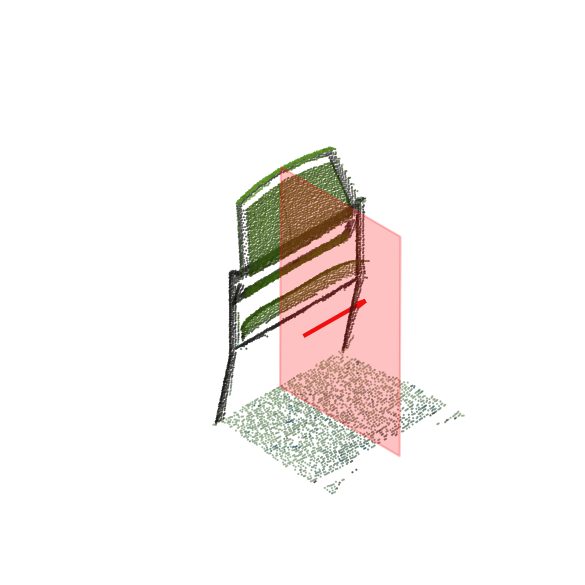

In [ ]:
fig = visualize_symmetry_static(sym, pcd, show_grid=False, show_axis=False, point_size=1, show_title=False)
fig.savefig("symmetry.png", bbox_inches="tight", transparent=True)

In [35]:
def process_symmetry_batch(
    data_folder:  str | Path,
    output_folder: str | Path,
) -> None:
    """
    Find all *_points.txt files under data_folder, detect symmetry, and save
    a static isometric symmetry plot to output_folder.

    Output filenames mirror the input structure with _points.txt → _symmetry.png.

    Args:
        data_folder:   Root folder to search recursively for *_points.txt files.
        output_folder: Folder where *_symmetry.png files are saved (created if needed).
    """
    data_folder   = Path(data_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    files = sorted(data_folder.rglob("*_points.txt"))
    if not files:
        print(f"No *_points.txt files found under {data_folder}")
        return

    print(f"Found {len(files)} file(s) — processing...")

    for i, path in enumerate(files, 1):
        print(f"[{i}/{len(files)}] {path.name}", end=" ... ", flush=True)
        try:
            pcd, matrix = drm.txt_pcd_to_open3d(path)

            result = detect_symmetry_o3d(pcd, threshold=0.02, n_random_candidates=600)

            out_path = output_folder / path.name.replace("_points.txt", "_symmetry.png")

            fig = visualize_symmetry_static(
                result, pcd,
                show_grid=False,
                show_axis=False,
                point_size=1,
                show_title=False,
            )
            fig.savefig(out_path, bbox_inches="tight", transparent=True)
            plt.close(fig)

            print(f"saved → {out_path.name}")

        except Exception as e:
            print(f"FAILED — {e}")

process_symmetry_batch(r"/home/jvermandere/datasets/V-Scan/data", r"/home/jvermandere/datasets/V-Scan/symmetry_images")

Found 2694 file(s) — processing...
[1/2694] Cabinet White Grunge(Clone)1775813745533_points.txt ... Loaded 13566 points from /home/jvermandere/datasets/V-Scan/data/Industrial_1_Leica-P30_1775813745523/Cabinet White Grunge(Clone)1775813745533_points.txt
[symmetry] 13566 pts | 873 candidates | thr=0.020
[symmetry] Initial best score : 0.7797
[symmetry]   refine 1/6: score=0.7984
[symmetry]   refine 2/6: score=0.7984
[symmetry] Final score  : 0.7984
[symmetry] Plane normal : [0.9999 0.0129 0.0056]
[symmetry] Plane point  : [-0.0102  0.2907  0.7553]
saved → Cabinet White Grunge(Clone)1775813745533_symmetry.png
[2/2694] Cabinet White Grunge(Clone)1775813745536_points.txt ... Loaded 3195 points from /home/jvermandere/datasets/V-Scan/data/Industrial_1_Leica-P30_1775813745523/Cabinet White Grunge(Clone)1775813745536_points.txt
[symmetry] 3195 pts | 873 candidates | thr=0.020
[symmetry] Initial best score : 0.9934
[symmetry]   refine 1/6: score=0.9934
[symmetry] Final score  : 0.9934
[symmetry]

KeyboardInterrupt: 

In [37]:
def process_symmetry_batch_shapenet(
    data_folder:   str | Path,
    output_folder: str | Path,
) -> None:
    """
    Find all model_normalized.obj files under data_folder, simulate a partial
    view, detect symmetry, and save a static isometric symmetry plot.

    Output mirrors the input structure with model_normalized.obj → symmetry.png,
    saved flat in output_folder using the two parent folder names as a prefix:
    e.g. 03001627_f595abef9bc7320944b2fa2cac0778f5_symmetry.png

    Args:
        data_folder:   Root folder to search recursively for model_normalized.obj.
        output_folder: Folder where *_symmetry.png files are saved (created if needed).
    """
    data_folder   = Path(data_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    files = sorted(data_folder.rglob("model_normalized.obj"))
    if not files:
        print(f"No model_normalized.obj files found under {data_folder}")
        return

    print(f"Found {len(files)} file(s) — processing...")

    for i, path in enumerate(files, 1):
        # e.g. 03001627_f595abef9bc7320944b2fa2cac0778f5
        category_id = path.parts[-4]   # .../03001627/
        model_id    = path.parts[-3]   # .../f595abef.../
        label       = f"{category_id}_{model_id}"

        print(f"[{i}/{len(files)}] {label}", end=" ... ", flush=True)
        try:
            pcd_partial, cam = simulate_partial_view(load_shapenet_pcd(path))

            # Rotate Y-up (ShapeNet) → Z-up
            R_y_to_z = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]], dtype=np.float64)
            pcd_partial.rotate(R_y_to_z, center=(0, 0, 0))


            result = detect_symmetry_o3d(pcd_partial, threshold=0.02, n_random_candidates=600)

            out_path = output_folder / f"{label}_symmetry.png"

            fig = visualize_symmetry_static(
                result, pcd_partial,
                show_grid=False,
                show_axis=False,
                point_size=1,
                show_title=False,
            )
            fig.savefig(out_path, bbox_inches="tight", transparent=True)
            plt.close(fig)

            print(f"saved → {out_path.name}")

        except Exception as e:
            print(f"FAILED — {e}")

process_symmetry_batch_shapenet(r"/home/jvermandere/datasets/ShapeNet", r"/home/jvermandere/datasets/ShapeNet/symmetry_images")

Found 6778 file(s) — processing...
[1/6778] 03001627_1006be65e7bc937e9141f9b58470d646 ... [Open3D INFO] Skipping non-triangle primitive geometry of type: 2
[symmetry] 1151 pts | 871 candidates | thr=0.020
[symmetry] Initial best score : 0.6299
[symmetry]   refine 1/6: score=0.7211
[symmetry]   refine 2/6: score=0.8149
[symmetry]   refine 3/6: score=0.8202
[symmetry]   refine 4/6: score=0.8202
[symmetry] Final score  : 0.8202
[symmetry] Plane normal : [-1.     -0.0054  0.0031]
[symmetry] Plane point  : [ 0.004   0.0927 -0.1726]
saved → 03001627_1006be65e7bc937e9141f9b58470d646_symmetry.png
[2/6778] 03001627_1007e20d5e811b308351982a6e40cf41 ... [symmetry] 1101 pts | 872 candidates | thr=0.020
[symmetry] Initial best score : 0.4042
[symmetry]   refine 1/6: score=0.4042
[symmetry] Final score  : 0.4042
[symmetry] Plane normal : [-0.165   0.9863  0.003 ]
[symmetry] Plane point  : [-0.3357  0.0531 -0.2769]
saved → 03001627_1007e20d5e811b308351982a6e40cf41_symmetry.png
[3/6778] 03001627_100b1

KeyboardInterrupt: 

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
#  GLB loading
# ═══════════════════════════════════════════════════════════════════════════════

def load_glb_pcd(
    glb_path:  str | Path,
    n_points:  int  = 4096,
    method:    str  = "poisson",
    normalize: bool = True,
) -> o3d.geometry.PointCloud:
    """
    Load a .glb mesh and sample it into a point cloud.
    Identical contract to load_shapenet_pcd() but reads GLB format.
    """
    import trimesh

    scene = trimesh.load(str(glb_path), force="scene")

    # Merge all meshes in the scene into one
    if isinstance(scene, trimesh.Scene):
        geometries = [g for g in scene.geometry.values() if isinstance(g, trimesh.Trimesh)]
        if not geometries:
            raise ValueError(f"No triangle meshes found in: {glb_path}")
        mesh_tm = trimesh.util.concatenate(geometries)
    else:
        mesh_tm = scene

    # Convert to Open3D mesh
    mesh_o3d = o3d.geometry.TriangleMesh()
    mesh_o3d.vertices  = o3d.utility.Vector3dVector(np.array(mesh_tm.vertices,  dtype=np.float64))
    mesh_o3d.triangles = o3d.utility.Vector3iVector(np.array(mesh_tm.faces,     dtype=np.int32))
    mesh_o3d.compute_vertex_normals()

    if not mesh_o3d.has_vertices():
        raise ValueError(f"Could not load mesh or mesh is empty: {glb_path}")

    # Sample point cloud
    if method == "poisson":
        pcd = mesh_o3d.sample_points_poisson_disk(number_of_points=n_points, init_factor=5)
    else:
        pcd = mesh_o3d.sample_points_uniformly(number_of_points=n_points)

    if normalize:
        pts      = np.asarray(pcd.points)
        centroid = pts.mean(axis=0)
        scale    = np.linalg.norm(pts - centroid, axis=1).max()
        if scale > 1e-8:
            pcd.points = o3d.utility.Vector3dVector((pts - centroid) / scale)

    return pcd


# ═══════════════════════════════════════════════════════════════════════════════
#  GLB class benchmark  (mirrors benchmark_class but reads glb/ subfolders)
# ═══════════════════════════════════════════════════════════════════════════════

# ShapeNet Y-up → Z-up
_R_Y_TO_Z = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]], dtype=np.float64)


def benchmark_class_glb(
    class_dir:      str | Path,
    output_dir:     str | Path,
    n_shapes:       Optional[int]  = None,
    n_points:       int            = 4096,
    sample_method:  str            = "poisson",
    distance:       float          = 2.5,
    radius_factor:  float          = 100.0,
    k:              int            = 3,
    sym_kwargs:     Optional[dict] = None,
    max_match_deg:  float          = 45.0,
    seed:           int            = 42,
    verbose:        bool           = True,
) -> ClassBenchmarkResult:
    """
    Run the full→partial multi-axis symmetry benchmark for one GLB class folder.

    Folder layout expected:
        class_dir/
            <model_id>.glb
            ...

    For each shape:
      - loads the GLB mesh and samples a point cloud
      - rotates Y-up → Z-up (ShapeNet convention)
      - simulates a partial view via HPR
      - detects K symmetry axes on both full and partial clouds
      - saves a symmetry visualisation PNG to output_dir/class_name/

    Parameters
    ----------
    class_dir     : path to the class folder, e.g. `.../glb/bed`
    output_dir    : root output folder; a subfolder per class is created inside
    n_shapes      : how many shapes to evaluate (None = all)
    n_points      : points to sample per mesh
    sample_method : "poisson" or "uniform"
    distance      : HPR camera distance
    radius_factor : HPR radius = distance * radius_factor
    k             : number of symmetry axes to detect per cloud
    sym_kwargs    : extra kwargs for detect_multi_symmetry_o3d()
    max_match_deg : angle threshold for declaring an axis pair matched
    seed          : base RNG seed
    verbose       : print per-shape progress

    Returns
    -------
    ClassBenchmarkResult
    """
    class_dir  = Path(class_dir)
    class_name = class_dir.name                        # e.g. "bed"
    synset_id  = {v: k for k, v in SHAPENET_SYNSETS.items()}.get(class_name, class_name)

    out_class_dir = Path(output_dir) / class_name
    out_class_dir.mkdir(parents=True, exist_ok=True)

    glb_files = sorted(class_dir.glob("*.glb"))
    if not glb_files:
        raise FileNotFoundError(f"No .glb files found under {class_dir}")

    if n_shapes is not None:
        rng_sel  = np.random.default_rng(seed)
        glb_files = list(rng_sel.choice(glb_files, size=min(n_shapes, len(glb_files)), replace=False))

    if verbose:
        print(f"\n[benchmark_glb] {class_name} ({synset_id}) | {len(glb_files)} shapes | k={k}")

    per_shape: List[ShapeSymmetryResult] = []

    for i, glb_path in enumerate(glb_files):
        shape_seed = seed + i
        model_id   = glb_path.stem

        try:
            pcd_full = load_glb_pcd(glb_path, n_points=n_points, method=sample_method)

            # Rotate Y-up (ShapeNet/GLB) → Z-up
            pcd_full.rotate(_R_Y_TO_Z, center=(0, 0, 0))

            pcd_partial, cam = simulate_partial_view(
                pcd_full, distance=distance, radius_factor=radius_factor, seed=shape_seed,
            )

            if len(pcd_partial.points) < 50:
                if verbose:
                    print(f"  [{i+1}/{len(glb_files)}] SKIP {model_id} "
                          f"(only {len(pcd_partial.points)} visible pts)")
                continue

            result = compare_symmetry(
                pcd_full, pcd_partial, cam,
                obj_path  = str(glb_path),
                k         = k,
                sym_kwargs= sym_kwargs,
                max_match_deg = max_match_deg,
            )
            per_shape.append(result)

            # ── Save symmetry visualisation ───────────────────────────────────
            try:
                fig = visualize_symmetry_static(
                    result.multi_partial.axes[0],   # best partial axis
                    pcd_partial,
                    show_grid  = False,
                    show_axis  = False,
                    point_size = 1,
                    show_title = False,
                )
                fig.savefig(
                    out_class_dir / f"{model_id}_symmetry.png",
                    bbox_inches="tight",
                    transparent=True,
                )
                plt.close(fig)
            except Exception as vis_exc:
                if verbose:
                    print(f"    [vis] WARNING: {vis_exc}")

            if verbose:
                frac     = result.n_points_partial / result.n_points_full
                err_strs = "  ".join(
                    f"ax{m.partial_rank}:{m.angular_error_deg:4.1f}°{'✓' if m.found else '✗'}"
                    for m in result.axis_matches
                )
                print(f"  [{i+1:>3}/{len(glb_files)}] {model_id[:24]:<24}  "
                      f"vis={frac*100:.0f}%  {err_strs}")

        except Exception as exc:
            if verbose:
                print(f"  [{i+1}/{len(glb_files)}] ERROR {model_id}: {exc}")

    if not per_shape:
        raise RuntimeError(f"No shapes successfully processed in {class_dir}")

    # ── Per-rank aggregation (identical to benchmark_class) ───────────────────
    errors_by_rank: List[List[float]] = [[] for _ in range(k)]
    found_by_rank:  List[List[bool]]  = [[] for _ in range(k)]

    for r in per_shape:
        for m in r.axis_matches:
            if m.partial_rank < k:
                errors_by_rank[m.partial_rank].append(m.angular_error_deg)
                found_by_rank[m.partial_rank].append(m.found)

    all_errors = [e for rank_errors in errors_by_rank for e in rank_errors]

    cls_result = ClassBenchmarkResult(
        synset_id  = synset_id,
        class_name = class_name,
        n_shapes   = len(per_shape),
        k          = k,

        errors_by_rank = errors_by_rank,
        found_by_rank  = found_by_rank,

        mean_angular_error_deg = float(np.mean(all_errors)) if all_errors else 90.0,
        std_angular_error_deg  = float(np.std(all_errors))  if all_errors else 0.0,

        mean_error_by_rank = [
            float(np.mean(errs)) if errs else 90.0 for errs in errors_by_rank
        ],
        found_rate_by_rank = [
            float(np.mean(founds)) if founds else 0.0 for founds in found_by_rank
        ],

        mean_fraction_visible = float(np.mean(
            [r.n_points_partial / r.n_points_full for r in per_shape]
        )),
        mean_score_full    = float(np.mean([r.mean_score_full    for r in per_shape])),
        mean_score_partial = float(np.mean([r.mean_score_partial for r in per_shape])),

        per_shape = per_shape,
    )

    if verbose:
        print(cls_result)

    return cls_result


# ═══════════════════════════════════════════════════════════════════════════════
#  GLB dataset benchmark  (mirrors benchmark_dataset)
# ═══════════════════════════════════════════════════════════════════════════════

def benchmark_dataset_glb(
    glb_root:      str | Path,
    output_dir:    str | Path,
    class_names:   Optional[List[str]] = None,
    n_per_class:   Optional[int]       = 20,
    n_points:      int                 = 4096,
    sample_method: str                 = "poisson",
    distance:      float               = 2.5,
    radius_factor: float               = 100.0,
    k:             int                 = 3,
    sym_kwargs:    Optional[dict]      = None,
    max_match_deg: float               = 45.0,
    seed:          int                 = 42,
    verbose:       bool                = True,
) -> Dict[str, ClassBenchmarkResult]:
    """
    Run the GLB benchmark across multiple class folders and print a summary table.

    Folder layout expected:
        glb_root/
            bed/
                <model_id>.glb
            chair/
                <model_id>.glb
            ...

    Parameters
    ----------
    glb_root     : root folder containing one subfolder per class
    output_dir   : root output folder; one subfolder per class is created
    class_names  : which class subfolders to run (None = all subfolders)
    n_per_class  : shapes per class (None = all)
    ...          : same as benchmark_class_glb

    Returns
    -------
    dict mapping class_name → ClassBenchmarkResult
    """
    glb_root   = Path(glb_root)
    output_dir = Path(output_dir)

    if class_names is None:
        class_names = [
            d.name for d in sorted(glb_root.iterdir())
            if d.is_dir() and not d.name.startswith(".")
        ]

    results: Dict[str, ClassBenchmarkResult] = {}

    for offset, cls in enumerate(class_names):
        class_dir = glb_root / cls
        if not class_dir.exists():
            if verbose:
                print(f"[benchmark_glb] Skipping {cls}: folder not found.")
            continue
        try:
            r = benchmark_class_glb(
                class_dir     = class_dir,
                output_dir    = output_dir,
                n_shapes      = n_per_class,
                n_points      = n_points,
                sample_method = sample_method,
                distance      = distance,
                radius_factor = radius_factor,
                k             = k,
                sym_kwargs    = sym_kwargs,
                max_match_deg = max_match_deg,
                seed          = seed + offset * 10000,
                verbose       = verbose,
            )
            results[cls] = r
        except Exception as exc:
            if verbose:
                print(f"[benchmark_glb] ERROR on {cls}: {exc}")

    if verbose and results:
        _print_summary_table({r.synset_id: r for r in results.values()})

    return results


In [ ]:

# Full dataset
results = benchmark_dataset_glb(
    glb_root   = "/home/jvermandere/datasets/ShapeNet/glb",
    output_dir = "/home/jvermandere/datasets/ShapeNet/symmetry_results",
    n_per_class= 20,
    k          = 3,
)

In [45]:
import csv
from pathlib import Path


def save_benchmark_to_csv(
    results:     Dict[str, ClassBenchmarkResult],
    output_path: str | Path,
) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    # ── Per-shape CSV ─────────────────────────────────────────────────────────
    per_shape_path = output_path.parent / (output_path.stem + "_per_shape.csv")
    with open(per_shape_path, "w", newline="") as f:
        writer = csv.writer(f)
        max_k  = max(r.k for r in results.values())

        axis_cols = []
        for rank in range(max_k):
            label = {0: "primary", 1: "secondary", 2: "tertiary"}.get(rank, f"rank{rank}")
            axis_cols += [
                f"{label}_partial_normal", f"{label}_partial_score",
                f"{label}_full_normal",    f"{label}_full_score",
                f"{label}_error_deg",      f"{label}_found",
            ]

        writer.writerow([
            "class_name", "synset_id", "model_id", "obj_path",
            "n_points_full", "n_points_partial", "fraction_visible",
            "n_axes_full", "n_axes_partial",
            "mean_score_full", "mean_score_partial",
            "found_fraction",
            "elapsed_full_s", "elapsed_partial_s",
            "camera_x", "camera_y", "camera_z",
            *axis_cols,
        ])

        for class_name, cls_result in results.items():
            synset_id = cls_result.synset_id
            for shape in cls_result.per_shape:
                model_id = Path(shape.obj_path).stem
                cam      = shape.camera_pos

                axis_vals = []
                for rank in range(max_k):
                    match = next((m for m in shape.axis_matches if m.partial_rank == rank), None)
                    if match:
                        pn = f"[{match.partial_normal[0]:.4f},{match.partial_normal[1]:.4f},{match.partial_normal[2]:.4f}]"
                        fn = f"[{match.full_normal[0]:.4f},{match.full_normal[1]:.4f},{match.full_normal[2]:.4f}]"
                        axis_vals += [pn, f"{match.partial_score:.4f}",
                                      fn, f"{match.full_score:.4f}",
                                      f"{match.angular_error_deg:.4f}", match.found]
                    else:
                        axis_vals += ["N/A", "N/A", "N/A", "N/A", "N/A", "N/A"]

                writer.writerow([
                    class_name, synset_id, model_id, shape.obj_path,
                    shape.n_points_full, shape.n_points_partial,
                    f"{shape.n_points_partial / shape.n_points_full:.4f}",
                    shape.multi_full.k, shape.multi_partial.k,
                    f"{shape.mean_score_full:.4f}", f"{shape.mean_score_partial:.4f}",
                    f"{shape.found_fraction:.4f}",
                    f"{shape.elapsed_full_s:.4f}", f"{shape.elapsed_partial_s:.4f}",
                    f"{cam[0]:.4f}", f"{cam[1]:.4f}", f"{cam[2]:.4f}",
                    *axis_vals,
                ])

    print(f"Saved per-shape CSV  → {per_shape_path}")

    # ── Summary CSV ───────────────────────────────────────────────────────────
    summary_path = output_path.parent / (output_path.stem + "_summary.csv")
    with open(summary_path, "w", newline="") as f:
        writer = csv.writer(f)
        max_k  = max(r.k for r in results.values())

        rank_cols = []
        for rank in range(max_k):
            label = {0: "primary", 1: "secondary", 2: "tertiary"}.get(rank, f"rank{rank}")
            rank_cols += [f"{label}_mean_error_deg_found", f"{label}_found_rate"]

        writer.writerow([
            "class_name", "synset_id", "n_shapes",
            "mean_error_deg_found", "std_error_deg_found",
            *rank_cols,
            "mean_fraction_visible",
            "mean_score_full", "mean_score_partial",
        ])

        for class_name, r in results.items():
            rank_vals = []
            for rank in range(max_k):
                if rank < len(r.errors_by_rank):
                    found_errors = [
                        e for e, found in zip(r.errors_by_rank[rank], r.found_by_rank[rank])
                        if found
                    ]
                    mean_e  = float(np.mean(found_errors)) if found_errors else "N/A"
                    found_r = r.found_rate_by_rank[rank] if rank < len(r.found_rate_by_rank) else "N/A"
                else:
                    mean_e, found_r = "N/A", "N/A"

                rank_vals += [
                    f"{mean_e:.4f}"  if isinstance(mean_e,  float) else mean_e,
                    f"{found_r:.4f}" if isinstance(found_r, float) else found_r,
                ]

            all_found_errors = [
                e
                for rank in range(len(r.errors_by_rank))
                for e, found in zip(r.errors_by_rank[rank], r.found_by_rank[rank])
                if found
            ]
            mean_e_overall = float(np.mean(all_found_errors)) if all_found_errors else "N/A"
            std_e_overall  = float(np.std(all_found_errors))  if all_found_errors else "N/A"

            writer.writerow([
                class_name, r.synset_id, r.n_shapes,
                f"{mean_e_overall:.4f}" if isinstance(mean_e_overall, float) else mean_e_overall,
                f"{std_e_overall:.4f}"  if isinstance(std_e_overall,  float) else std_e_overall,
                *rank_vals,
                f"{r.mean_fraction_visible:.4f}",
                f"{r.mean_score_full:.4f}", f"{r.mean_score_partial:.4f}",
            ])

    print(f"Saved summary CSV    → {summary_path}")

save_benchmark_to_csv(results, "/home/jvermandere/datasets/ShapeNet/symmetry_results_outlier_removed")

Saved per-shape CSV  → /home/jvermandere/datasets/ShapeNet/symmetry_results_outlier_removed_per_shape.csv


AttributeError: 'ClassBenchmarkResult' object has no attribute 'found_by_rank'